## Generalized Laplace Active Subspace UQ for an anatyical test function

Notebook to reproduce the results from section *Regression with known observational noise* of

W.N. Edeling, P.V. Coveney, *Scalable Neural Network Uncertainty Quantification via Generalized Laplace
Active Subspaces*, 2026, (submitted).


Missing packages can be installed using e.g.:

In [1]:
#!pip install tqdm

In [2]:
import torch
import torch.nn as nn
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from tqdm import tqdm

# various subroutines we use for the generalized laplace active subspaces, see ./utils/__init__.py
import utils

We employ the following analytic test function with known $\sigma=0.1$:

\begin{align}
 y(x) = \sin(4\pi x) + \sin(7\pi x) + \epsilon, \quad \epsilon\sim\mathcal{N}(0, \sigma^2), \quad x\in [0,1],
\end{align}

In [3]:
def f_np(x, sigma=0.4):
    eps = np.random.randn(*x.shape) * sigma
    return np.sin(4 * np.pi * x) + np.sin(7 * np.pi * x) + eps

Fix the random seeds

In [4]:
torch.manual_seed(0)
np.random.seed(0)

### Generate training data

In [5]:
# number of data points
N = 50
# indepedent x variable
x_np = np.linspace(0, 1, N).reshape(-1, 1)

# known noise
sigma = 0.1

# data: y = f(x) + epsilon
y_np = f_np(x_np, sigma = sigma)

# store in tensors
x = torch.tensor(x_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32)

### Choose scaling

The temperature parameter $\beta$ is used to select either the standard Bayesian scaling (related to the summed loss), or the generalized scaling (related to the mean loss).

In [6]:
beta = 1 / sigma ** 2          # generalized scaling (regression)
# beta = N / sigma ** 2        # standard scaling (regression)

# a flag for the type of scaling used: generalized or standard
if beta > 1 / sigma ** 2: scaling = 'std'
else: scaling = 'gen'

The maximium subspace dimension that we consider

In [7]:
d_max = 50

### Create neural network

This creates a very simple feed forward neural network with 2 layers with `n_neurons` neurons per layer

In [8]:
class Net(nn.Module):
    def __init__(self, n_neurons):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, n_neurons),
            nn.Tanh(),
            nn.Linear(n_neurons, n_neurons),
            nn.Tanh(),
            nn.Linear(n_neurons, 1)
        )

    def forward(self, x):
        return self.net(x)

In [9]:
n_neurons = 50
model = Net(n_neurons)
# number of connection weights
D = sum([p.numel() for p in model.parameters()])
print(f'There are D = {D} connection weights')

There are D = 2701 connection weights


### Train neural network

Train the network using standard back propagation techniques, and a **mean** squared loss.

In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
for i in range(5000):
    pred = model(x)
    loss = (0.5*(pred - y)**2).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if np.mod(i, 1000) == 0:
        print(f'Loss at iteration {i} = {loss.item():.3e}')

Loss at iteration 0 = 4.868e-01
Loss at iteration 1000 = 3.626e-03
Loss at iteration 2000 = 2.788e-03
Loss at iteration 3000 = 2.548e-03
Loss at iteration 4000 = 2.398e-03


In [11]:
model.eval()

Net(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=50, bias=True)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): Tanh()
    (4): Linear(in_features=50, out_features=1, bias=True)
  )
)

Plot fit:

/tmp/ipykernel_55161/2872888256.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=0, frameon=False)


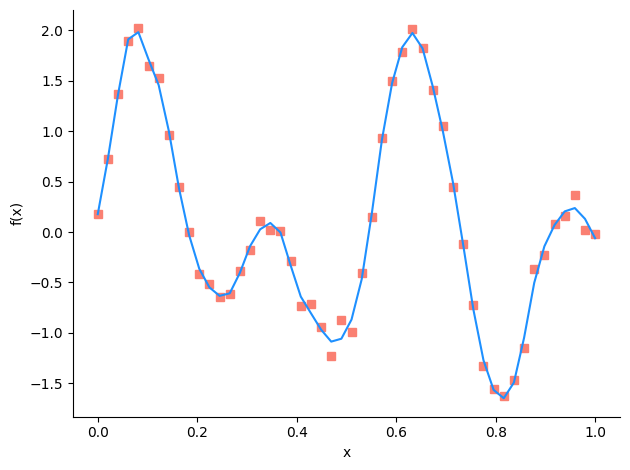

In [12]:
with torch.no_grad():
    fig = plt.figure()
    ax = fig.add_subplot(111, xlabel='x', ylabel='f(x)')
    ax.plot(x_np, y_np, 's', color='salmon')
    ax.plot(x, model(x), 'dodgerblue')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False) 
    plt.legend(loc=0, frameon=False)
    plt.tight_layout()

### Extract the pretrained weights

In [13]:
# a dictionary containing the weights names and weights tensors
# (without a .clone() small changes can creep in the pretrained weights during sampling)
theta_0_dict = {
    name: p.detach().clone()
    for name, p in model.named_parameters()
}
# all the weights reshaped into a Dx1 tensor
theta_0 = utils.dict_to_vector(theta_0_dict, model).detach().clone()

### Explicit computation of the generalized Gauss Newton matrix

Since $D$ is small enough, we explicitly form $G$ to verify the matrix-free implementation of the $Gv$ products and Lanczos eigenmodes.

In [14]:
def compute_G(model, x):
    """
    model : Net
        PyTorch model
    x     : tensor
        The independent x variable
    """

    params = [p for p in model.parameters() if p.requires_grad]

    G = torch.zeros(D, D)

    for n in tqdm(range(x.shape[0])):
        model.zero_grad()

        # forward pass (scalar output)
        f_n = model(x[n:n+1])  # shape (1, 1) or (1,)
        f_n = f_n.squeeze()

        # compute gradient df/dθ
        grads = torch.autograd.grad(f_n, params, retain_graph=False, create_graph=False)

        # flatten into single vector J (D x 1)
        J = torch.cat([g.reshape(-1) for g in grads]).unsqueeze(1)  # (D,1)

        # accumulate G
        G += (J @ J.T) / (N)

    return G

In [15]:
# form D x D G matrix
G = compute_G(model, x)
# compute eigenvalues / vectors and flip order (from low --> high to high --> low)
eigvals_G, eigvecs_G = torch.linalg.eigh(G)
eigvals_G = eigvals_G.flip(0)[0:d_max]
eigvecs_G = eigvecs_G.flip(1)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 62.92it/s]


### Matrix-free $Gv$ computation and comparison

Compute the $Gv$ product using forward and backward automatric differentiation, and compare with the explicit product.

In [16]:
# random v vector stored in a dict with the same structure as params
v_dict = {name: torch.randn_like(p) for name, p in theta_0_dict.items()}
# compute Gv using mini batches and autodiff
Gv = utils.batch_compute_Gv(model, theta_0_dict, v_dict, x, N, batch_size = N)

Computing Gv over 1 batches...


In [17]:
# explicit Gv product
v_vector = utils.dict_to_vector(v_dict, model)
Gv_vector_check = G @ v_vector

/tmp/ipykernel_55161/2078276143.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  p3 = ax2.plot(np.arange(1, D+1), np.abs(Gv - Gv_vector_check), 'dodgerblue', alpha=0.5,


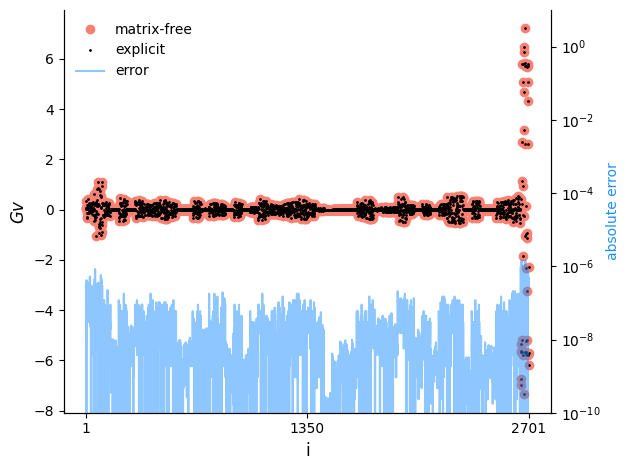

In [18]:
# recreate the plot 
with torch.no_grad():
    fig = plt.figure('Gv')
    ax = fig.add_subplot(111)
    p1 = ax.plot(np.arange(1, D+1), Gv, 'o', color = 'salmon', label='matrix-free')
    p2 = ax.plot(np.arange(1, D+1), Gv_vector_check, '.', color='k', markersize=2, label='explicit')
    ax.set_xlabel('i', fontsize=12)
    ax.set_ylabel(r'$Gv$', fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.set_xticks([1, int(D/2), D])

    ax2 = plt.twinx(ax)
    p3 = ax2.plot(np.arange(1, D+1), np.abs(Gv - Gv_vector_check), 'dodgerblue', alpha=0.5,
             label=r'error')
    ax2.set_yscale('log')
    ax2.set_ylim([1e-10, 1e1])
    ax2.spines['top'].set_visible(False)
    ax2.set_ylabel('absolute error', color='dodgerblue')

    # collect labels from all axes, plot in single legend
    lns = p1 + p2 + p3
    labs = [l.get_label() for l in lns]
    plt.legend(lns, labs, loc=2, frameon=False, draggable=True)
    plt.tight_layout()

### Matrix-free $G$ eigenmodes and comparison

Here we compute the dominant eigenvalues/vectors of $G$ using matrix-free $Gv$ products and the Lanczos algorithm, see Section *Matrix-free computation of dominant eigenpairs*.

In [19]:
m = d_max + 10 
Q, T = utils.lanczos(m, D, model, theta_0_dict, x, N, batch_size = N)
# eigen decomposition of small matrix
eigvals, eigvecs_T = torch.linalg.eigh(T)
# map back to parameter space
eigvecs = Q @ eigvecs_T
# reserve sorting order, which is standard from low to high eigenvalues
eigvals = eigvals.flip(0)
eigvecs = eigvecs.flip(1)

Running Lanczos iterations...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 60/60 [00:00<00:00, 337.26it/s]

Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computing Gv over 1 batches...
Computin

/tmp/ipykernel_55161/909698354.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  p3 = ax2.plot(np.abs(eigvals[0:d_max] - eigvals_G[0:d_max]), 'dodgerblue', alpha=0.5,
/tmp/ipykernel_55161/909698354.py:40: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  p3 = ax2.plot(np.arange(1, D+1), np.abs(eigvecs[:,0] - eigvecs_G[:,0]), 'dodgerblue', alpha=0.5,


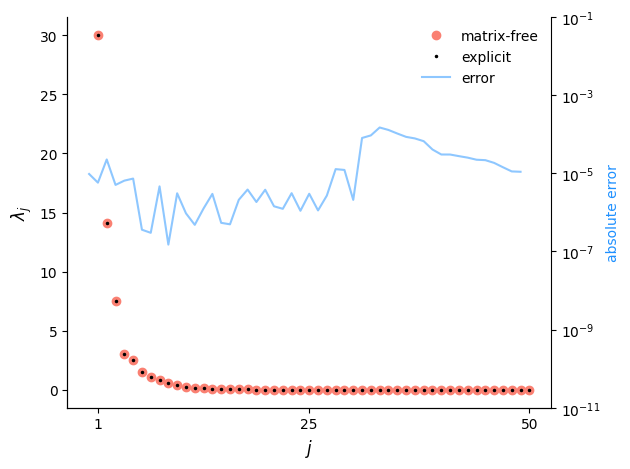

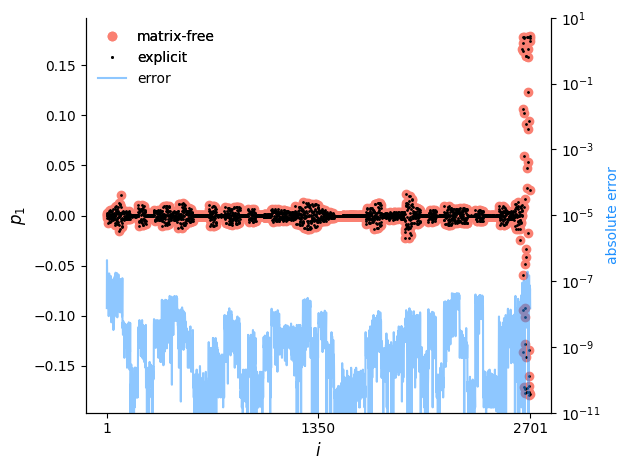

In [20]:
# compare again against direct computation
with torch.no_grad():
    # plot the d leading eigenvalues
    fig = plt.figure('eigvals')
    ax = fig.add_subplot(111)
    p1 = ax.plot(np.arange(1, d_max+1), eigvals[0:d_max], 'o', color = 'salmon', label='matrix-free')
    p2 = ax.plot(np.arange(1, d_max+1), eigvals_G[0:d_max], '.', color='k', markersize=3, label='explicit')
    ax.set_ylabel(r'$\lambda_j$', fontsize=12)
    ax.set_xlabel(r'$j$', fontsize=12)
    ax.set_xticks([1, int(d_max/2), d_max])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax2 = plt.twinx(ax)
    p3 = ax2.plot(np.abs(eigvals[0:d_max] - eigvals_G[0:d_max]), 'dodgerblue', alpha=0.5,
             label=r'error')
    ax2.set_yscale('log')
    ax2.set_ylim([1e-11, 1e-1])
    ax2.spines['top'].set_visible(False)
    ax2.set_ylabel('absolute error', color='dodgerblue')

    # collect labels from all axes, plot in single legend
    lns = p1 + p2 + p3
    labs = [l.get_label() for l in lns]
    plt.legend(lns, labs, loc=1, frameon=False, draggable=True)
    plt.tight_layout()
        
    # plot the leading eigenvector
    fig = plt.figure('leading_eigvec')
    ax = fig.add_subplot(111)
    p1 = ax.plot(np.arange(1, D+1), eigvecs[:,0], 'o', color = 'salmon', label='matrix-free')
    p2 = ax.plot(np.arange(1, D+1), eigvecs_G[:,0], '.', color='k', markersize=2, label='explicit')
    plt.legend(loc=0, frameon=False)
    ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)
    ax.set_ylabel(r'$p_1$', fontsize=12)
    ax.set_xlabel(r'$i$', fontsize=12)
    ax.set_xticks([1, int(D/2), D])
    
    ax2 = plt.twinx(ax)
    p3 = ax2.plot(np.arange(1, D+1), np.abs(eigvecs[:,0] - eigvecs_G[:,0]), 'dodgerblue', alpha=0.5,
             label=r'error')
    ax2.set_yscale('log')
    ax2.set_ylim([1e-11, 1e1])
    ax2.spines['top'].set_visible(False)
    ax2.set_ylabel('absolute error', color='dodgerblue')

    # collect labels from all axes, plot in single legend
    lns = p1 + p2 + p3
    labs = [l.get_label() for l in lns]
    plt.legend(lns, labs, loc=2, frameon=False, draggable=True)
    plt.tight_layout()


### Emprical Bayes for $\sigma_0$ and calibration of $d$

We use an empirical Bayesian procedure to estimate the prior variance $\sigma_0^2$ from the data $y$, see section *"Empirical generalized Bayesian subspace inference for the prior variance"*.

We generate some calibration data:

In [21]:
# generate validation data
N_cal = 100
x_cal_np = np.random.rand(N_cal)
y_cal_np = f_np(x_cal_np, sigma)
x_cal = torch.tensor(x_cal_np, dtype=torch.float32)
y_cal = torch.tensor(y_cal_np, dtype=torch.float32)

We then loop over $d=1,2,\cdots$, computing $\sigma_0$ at each $d$ by solving:

\begin{align}
\lVert w_0\rVert^2_2 = \sum_{i=1}^d \frac{1}{\alpha} - \frac{1}{\beta\lambda_i + \alpha} = \sum_{i=1}^d \sigma^2_0 - \sigma^2_i,
\end{align}

via the bisection method (`utils.solve_sigma0_lowrank`). We select the first $(d, \sigma_0)$ pair for which the 90% confidence intervals contain at least 90% of the calibration data.

In [22]:
# number of Monte Carlo samples to compute the confidence intervals (CIs)
n_mc = 1000
# nominal CI
target_CI = 0.9
# locations which to evaluate the network
n_interp = 200
xx = torch.linspace(0, 1, n_interp).unsqueeze(1)
# counter for number of calibration data that fall in the CI
n_frac = 0
# candidate active subspace dimension
d_ = 0

# loop until thet required coverage or the maximum subspace dimension is reached
while n_frac < target_CI  and d_ < d_max:
    samples = torch.zeros([n_mc, n_interp])
    d_ += 1

    # projected weight norm (||w_0||^2_2)
    theta_0_projected = eigvecs[:, 0:d_].T @ theta_0
    theta_norm_sq_projected = (theta_0_projected**2).sum().item()
    # solve for prior variance 
    sigma0_sq = utils.solve_sigma0_lowrank(eigvals[0:d_], theta_norm_sq_projected, d_, beta)
    sigma_0 = np.sqrt(sigma0_sq)
    # closed form posterior variances
    sigma_sq_post = 1 / (beta * eigvals[0:d_] + 1 / sigma_0 ** 2)
    sigma_post = sigma_sq_post.sqrt()

    # posterior sampling using current d and sigma_0
    for i in tqdm(range(n_mc)):
        samples[i] = utils.sample(xx, model, theta_0, theta_0_dict, sigma_post, eigvecs[:, 0:d_])

    # compute CIs
    lower = torch.quantile(samples, (1 - target_CI) / 2, dim=0)
    upper = torch.quantile(samples, 1/2 + target_CI / 2 , dim=0)

    # check how many calibration data fall within the compute CIs
    with torch.no_grad():

        lower_np = lower.detach().cpu().numpy().flatten()
        upper_np = upper.detach().cpu().numpy().flatten()
        xx_np = xx.cpu().numpy().flatten()
        lower_interp = interp1d(xx_np, lower_np)
        upper_interp = interp1d(xx_np, upper_np)

        n_inside = 0
        for n in range(N_cal):
            lower_n = lower_interp(x_cal_np[n])
            upper_n = upper_interp(x_cal_np[n])
            if y_cal_np[n] >= lower_n and y_cal_np[n] <= upper_n:
                n_inside += 1
        n_frac = n_inside / N_cal
        print(f'{n_frac * 100}% of data points fall inside 90% CI for d = {d_}.')

# set the active subspace dimension to d_, recompute
d = d_
print(f'Active subspace dimension d = {d}, prior std. dev. = {sigma_0:.3e}')

Converged to root within -3.75e-09
alpha = 1512.6875000026137


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 2194.84it/s]


70.0% of data points fall inside 90% CI for d = 1.
Converged to root within -7.45e-09
alpha = 190.54833984630673


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 2580.84it/s]


93.0% of data points fall inside 90% CI for d = 2.
Active subspace dimension d = 2, prior std. dev. = 7.244e-02


### Contraction ratio

Plot the contraction ratio for the first `d_max` dominant directions of the $G$ eigenspace:

\begin{align}
c_i := \frac{\beta \lambda_i}{ \beta \lambda_i + \frac{1}{\sigma^2_0}},
\end{align}

for which $c_i = 1$ implies that the $i$-th direction is strongly data-informed, and values close to zero denote prior-dominated directions.

In the same figure we plot the posterior variance $\sigma_j^2$.

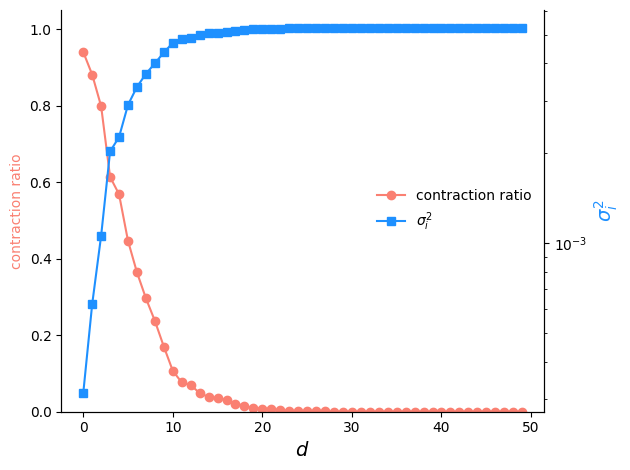

In [23]:
with torch.no_grad():
    eigvals_np = eigvals.cpu().numpy().flatten()
    contraction_ratio = beta * eigvals_np / (beta * eigvals_np + 1 / sigma_0 ** 2)
    var_post = 1 / (beta * eigvals_np + 1 / sigma_0 ** 2)

    fig = plt.figure()
    ax = fig.add_subplot(111, ylim=[0,1.05])
    p1 = ax.plot(contraction_ratio[0:d_max], '-o', color = 'salmon', label='contraction ratio')
    ax.set_xlabel(r'$d$', fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.set_ylabel('contraction ratio', color='salmon')
    
    ax2 = ax.twinx()
    p2 = ax2.plot(var_post[0:d_max], '-s', color = 'dodgerblue', label=r'$\sigma^2_i$')
    ax2.spines['top'].set_visible(False)
    ax2.set_yscale('log')
    ax2.set_ylabel(r'$\sigma^2_i$', color='dodgerblue', fontsize=14)
    
    lns = p1 + p2
    labs = [l.get_label() for l in lns]
    plt.legend(lns, labs, loc=5, frameon=False, draggable=True)
    plt.tight_layout()
    fig.savefig(f'./images/contraction_{scaling}_bayes_N{N}.png', dpi=300)

In [24]:
# set the final eigenvalues/vectors
# sigma_post = sigma_post[0:d]
# eigvecs = eigvecs[:, 0:d]

### Confindence interval plot

Recreate the confidence interval plots.

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 2948.79it/s]


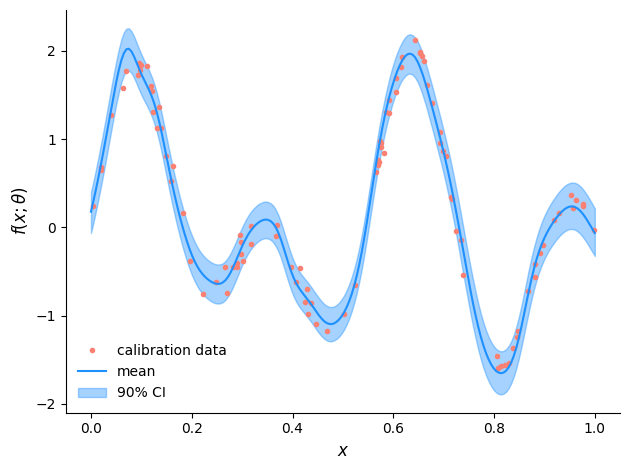

In [25]:
# sampling domain xx
n_mc = 1000
n_interp = 200
samples = torch.zeros([n_mc, n_interp])
xx = torch.linspace(0, 1.0, n_interp).unsqueeze(1)

# posterior sampling
for i in tqdm(range(n_mc)):
    samples[i] = utils.sample(xx, model, theta_0, theta_0_dict, sigma_post[0:d], eigvecs[:, 0:d])

# CIs
mean = samples.mean(dim=0)
lower = torch.quantile(samples, (1 - target_CI) / 2, dim=0)
upper = torch.quantile(samples, 1/2 + target_CI / 2 , dim=0)

# plot stuff
with torch.no_grad():

    mean_np = mean.detach().cpu().numpy().flatten()
    lower_np = lower.detach().cpu().numpy().flatten()
    upper_np = upper.detach().cpu().numpy().flatten()
    xx_np = xx.cpu().numpy().flatten()
    lower_interp = interp1d(xx_np, lower_np)
    upper_interp = interp1d(xx_np, upper_np)

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(x_cal_np, y_cal_np, '.', color='salmon', label='calibration data')
    ax.plot(xx, mean_np, 'dodgerblue', label='mean')

    ax.fill_between(
        xx.flatten(), 
        lower_np, 
        upper_np, 
        color='dodgerblue', 
        alpha=0.4, 
        label='90% CI'
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False) 
    ax.set_ylabel(r'$f(x; \theta)$', fontsize=12)
    ax.set_xlabel(r'$x$', fontsize=12)
    plt.legend(loc=0, frameon=False)
    plt.tight_layout()

### Linear Laplace

Linearized Laplace makes the a local linear approximation in the predictive model, keeping the posterior predictive mean fixed at the MAP prediction:

\begin{align}
    f(x;\theta) \approx f_{lin}(x; \theta) = f(x;\theta_0) + J(x)\left(\theta - \theta_0\right),
\end{align}

where $J(x):=\nabla_\theta f(x;\theta_0)\in\mathbb{R}^{M\times D}$. The combination of the linear output and the Gaussian distribution of $\theta$ also leads a closed-form predictive covariance $\Sigma_f=J\Sigma J^T$, where $\Sigma=P\Lambda P^T$, with $\Lambda:=\mathrm{diag}(\sigma^2_j)$ is our low-rank Laplace posterior covariance. In the case of scalar regression the (pointwise) posterior predictive variance becomes

\begin{align}
    \sigma^2_f(x) = \sum_{j=1}^d \sigma^2_j \left(J(x) p_j\right)^2\in\mathbb{R},
\end{align}
with $p_j\in\mathbb{R}^D$ denoting the j-th eigenvector of $P$, $P$ being the $D\times d$ projection matrix consisting of dominant eigenvectors of $G$.

Below we repeat the calibration procedure, except instead of sampling the nonlinear model, we now use $f(x;\theta_0)\pm 2\sigma_f$ as a 95% confidence interval. If this CI is not able to capture 95% of the calibration data, the algorithm will stop once $d=50$ is reached.

In [26]:
# nominal CI
target_CI = 0.95
# locations which to evaluate the network
n_interp = 200
xx = torch.linspace(0, 1, n_interp).unsqueeze(1)
# counter for number of calibration data that fall in the CI
n_frac = 0
# candidate active subspace dimension
d_ = 0

# loop until thet required coverage or the maximum subspace dimension is reached
while n_frac < target_CI  and d_ < d_max:
    d_ += 1

    # projected weight norm (||w_0||^2_2)
    theta_0_projected = eigvecs[:, 0:d_].T @ theta_0
    theta_norm_sq_projected = (theta_0_projected**2).sum().item()
    # solve for prior variance 
    sigma0_sq = utils.solve_sigma0_lowrank(eigvals[0:d_], theta_norm_sq_projected, d_, beta)
    sigma_0 = np.sqrt(sigma0_sq)
    # closed form posterior variances
    sigma_sq_post = 1 / (beta * eigvals[0:d_] + 1 / sigma_0 ** 2)
    sigma_post = sigma_sq_post.sqrt()

    # posterior linear Laplace using current d and sigma_0
    mean_f, std_f = utils.linear_laplace(xx, model, theta_0_dict, eigvecs, sigma_post, d_)

    # compute CIs
    lower = mean_f - 2 * std_f
    upper = mean_f + 2 * std_f

    # check how many calibration data fall within the compute CIs
    with torch.no_grad():

        lower_np = lower.detach().cpu().numpy().flatten()
        upper_np = upper.detach().cpu().numpy().flatten()
        xx_np = xx.cpu().numpy().flatten()
        lower_interp = interp1d(xx_np, lower_np)
        upper_interp = interp1d(xx_np, upper_np)

        n_inside = 0
        for n in range(N_cal):
            lower_n = lower_interp(x_cal_np[n])
            upper_n = upper_interp(x_cal_np[n])
            if y_cal_np[n] >= lower_n and y_cal_np[n] <= upper_n:
                n_inside += 1
        n_frac = n_inside / N_cal
        print(f'{n_frac * 100}% of data points fall inside 95% CI for d = {d_}.')

# set the active subspace dimension to d_, recompute
d = d_
print(f'Active subspace dimension d = {d}, prior std. dev. = {sigma_0:.3e}')

Converged to root within -3.75e-09
alpha = 1512.6875000026137
82.0% of data points fall inside 95% CI for d = 1.
Converged to root within -7.45e-09
alpha = 190.54833984630673
98.0% of data points fall inside 95% CI for d = 2.
Active subspace dimension d = 2, prior std. dev. = 7.244e-02


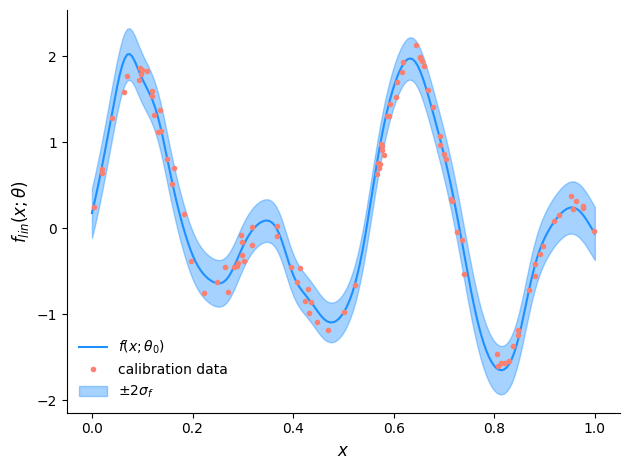

In [27]:
# get the mean and standard deviation from the linear laplace approximation
mean_f, std_f = utils.linear_laplace(xx, model, theta_0_dict, eigvecs[:, 0:d], sigma_post[0:d], d)

# plot the CIs
with torch.no_grad():

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(xx, mean_f, 'dodgerblue', label=r'$f(x; \theta_0)$')
    ax.plot(x_cal_np, y_cal_np, '.', color='salmon', label='calibration data')

    ax.fill_between(
        xx.flatten(), 
        (mean_f + 2 * std_f).squeeze(1), 
        (mean_f - 2 * std_f).squeeze(1), 
        color='dodgerblue', 
        alpha=0.4, 
        label=r'$\pm 2 \sigma_f$'
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False) 

    ax.set_ylabel(r'$f_{lin}(x; \theta)$', fontsize=12)
    ax.set_xlabel(r'$x$', fontsize=12)
    plt.legend(loc=0, frameon=False)
    plt.tight_layout()